# PCA + Random Forest para clasificar dígitos en MNIST

### Importamos las librerías y cargamos los datos.

In [1]:
# Importar librerías necesarias
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

In [2]:
# Cargar el conjunto de datos MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)  # Convertir etiquetas a enteros

# Dividir en conjunto de entrenamiento y prueba (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar dimensiones del dataset
print(f"Dimensiones del conjunto de entrenamiento: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba: {X_test.shape}")

c:\Users\Usuario\miniconda3\envs\titulo-propio-ia\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Dimensiones del conjunto de entrenamiento: (56000, 784)
Dimensiones del conjunto de prueba: (14000, 784)


### Ajustar el modelo y mostrar resultados 

In [3]:
# Entrenar un Random Forest sin PCA
rf = RandomForestClassifier(n_estimators=10, random_state=42)  # Solo 10 árboles para no tener accuracy muy alta

t0 = time.time()
rf.fit(X_train, y_train)
t1 = time.time()
train_no_pca = t1-t0

# Predicciones y evaluación
t0 = time.time()
y_pred = rf.predict(X_test)
t1 = time.time()
pred_no_pca = t1-t0

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy del Random Forest sin PCA: {accuracy:.4f}")

Accuracy del Random Forest sin PCA: 0.9456


### Matriz de Confusión y *Classification Report*

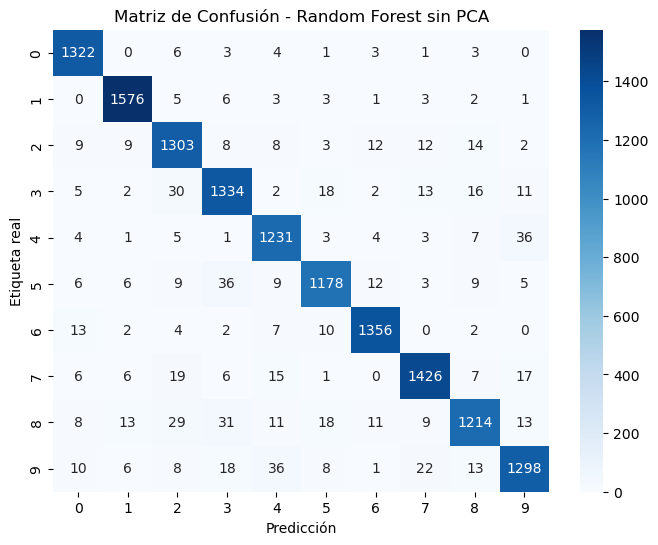

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1343
           1       0.97      0.98      0.98      1600
           2       0.92      0.94      0.93      1380
           3       0.92      0.93      0.93      1433
           4       0.93      0.95      0.94      1295
           5       0.95      0.93      0.94      1273
           6       0.97      0.97      0.97      1396
           7       0.96      0.95      0.95      1503
           8       0.94      0.89      0.92      1357
           9       0.94      0.91      0.93      1420

    accuracy                           0.95     14000
   macro avg       0.95      0.94      0.94     14000
weighted avg       0.95      0.95      0.95     14000



In [4]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión - Random Forest sin PCA")
plt.show()

# Mostrar classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

## Random Forest + PCA  

### Escalar la matriz de datos de entrada. 
Antes de aplicar PCA, debemos escalar los datos, ya que PCA es sensible a la escala de las variables. 
Aunque en MNIST los valores están entre 0 y 255, es recomendable estandarizarlos para que tengan media 0 y desviación estándar 1.


In [5]:
# Escalar los datos antes de aplicar PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mostrar la media y desviación estándar tras el escalado (deberían estar cerca de 0 y 1)
print(f"Media después de escalar: {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"Desviación estándar después de escalar: {X_train_scaled.std(axis=0).mean():.4f}")

Media después de escalar: -0.0000
Desviación estándar después de escalar: 0.9133


### Aplicamos PCA y graficamos la varianza que conservamos.

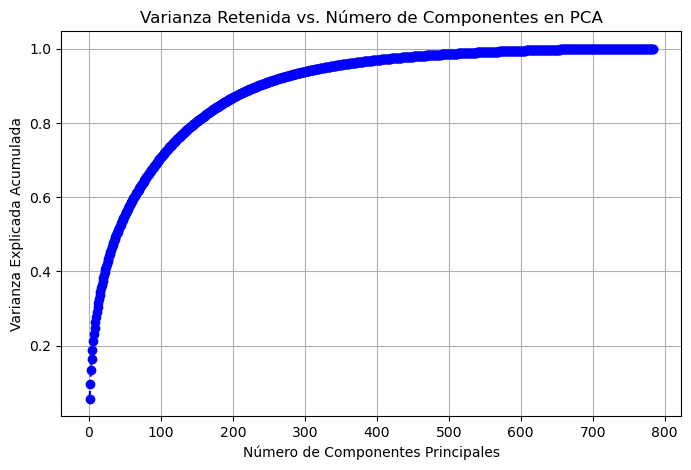

In [6]:
# Aplicar PCA sin limitar el número de componentes
pca = PCA()
pca.fit(X_train_scaled)

# Obtener la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Graficar la varianza retenida según el número de componentes
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b')
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Varianza Retenida vs. Número de Componentes en PCA")
plt.grid()
plt.show()

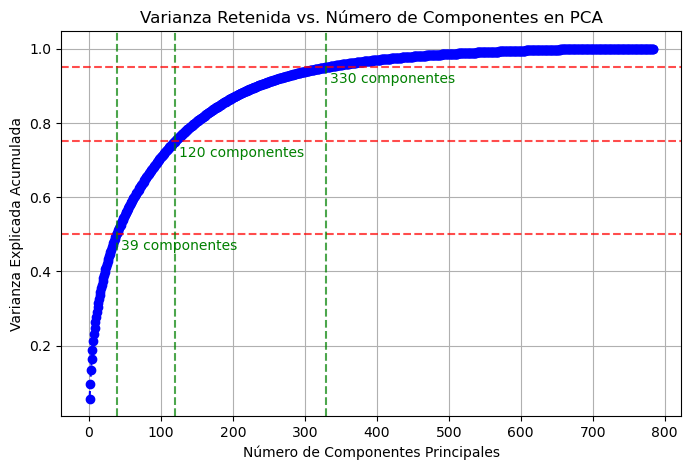

Para retener al menos el 50% de la varianza, se necesitan 39 componentes.
Para retener al menos el 75% de la varianza, se necesitan 120 componentes.
Para retener al menos el 95% de la varianza, se necesitan 330 componentes.


In [7]:
# Umbrales de varianza a marcar
umbrales = [0.50, 0.75, 0.95]
componentes_umbrales = [np.argmax(varianza_acumulada >= umbral) + 1 for umbral in umbrales]  # Obtener el número de componentes necesario para cada umbral

# Graficar la varianza retenida con umbrales
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b')

# Añadir líneas horizontales y verticales en los umbrales de varianza
for umbral, n_comp in zip(umbrales, componentes_umbrales):
    plt.axhline(y=umbral, color='r', linestyle='--', alpha=0.7)  # Línea horizontal
    plt.axvline(x=n_comp, color='g', linestyle='--', alpha=0.7)  # Línea vertical
    plt.text(n_comp + 5, umbral - 0.05, f"{n_comp} componentes", color='g', fontsize=10, verticalalignment='bottom')

# Etiquetas y título
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Varianza Retenida vs. Número de Componentes en PCA")
plt.grid()
plt.show()

# Mostrar el número de componentes necesarios para cada umbral
for umbral, n_comp in zip(umbrales, componentes_umbrales):
    print(f"Para retener al menos el {int(umbral * 100)}% de la varianza, se necesitan {n_comp} componentes.")

### PCA + Random Forest.

Ahora vamos a aplicar PCA reteniendo el 90% de la varianza y entrenar un Random Forest con la matriz de datos proyectada.

In [8]:
# Determinar el número de componentes necesarios para el 90% de la varianza
umbral_varianza = 0.90
n_componentes = np.argmax(varianza_acumulada >= umbral_varianza) + 1
print(f"Para retener el 90% de la varianza, usamos {n_componentes} componentes.")

# Aplicar PCA con el número de componentes adecuado
t0 = time.time()
pca_90 = PCA(n_components=n_componentes)
X_train_pca = pca_90.fit_transform(X_train_scaled)
X_test_pca = pca_90.transform(X_test_scaled)
t1 = time.time()
time_pca = t1-t0

# Entrenar un Random Forest sobre los datos proyectados con PCA
rf_pca = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)  # Mismos parámetros que antes
t0 = time.time()
rf_pca.fit(X_train_pca, y_train)
t1 = time.time()
train_pca = t1-t0

# Predicciones y evaluación
t0 = time.time()
y_pred_pca = rf_pca.predict(X_test_pca)
t1 = time.time()
pred_pca = t1-t0
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"Accuracy del Random Forest con PCA (90% varianza): {accuracy_pca:.4f}")

Para retener el 90% de la varianza, usamos 235 componentes.
Accuracy del Random Forest con PCA (90% varianza): 0.8886


### Matriz de Confusión y *Classification Report*


 Matriz de Confusión (Con PCA - 90% varianza):


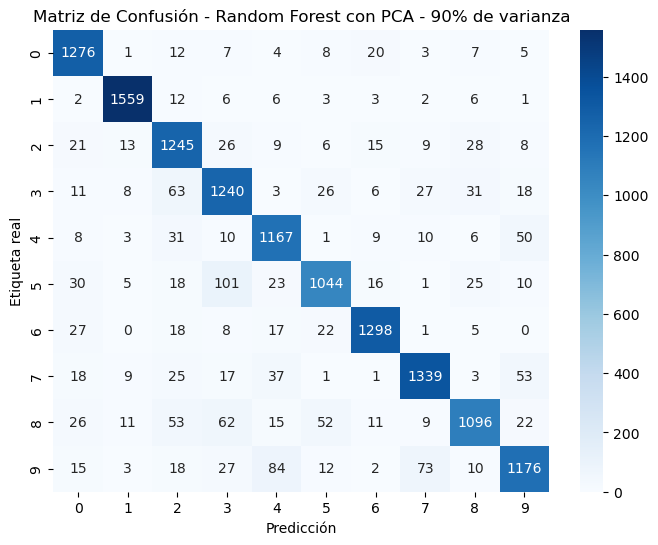


 Classification Report (Con PCA - 90% varianza):
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1343
           1       0.97      0.97      0.97      1600
           2       0.83      0.90      0.87      1380
           3       0.82      0.87      0.84      1433
           4       0.85      0.90      0.88      1295
           5       0.89      0.82      0.85      1273
           6       0.94      0.93      0.93      1396
           7       0.91      0.89      0.90      1503
           8       0.90      0.81      0.85      1357
           9       0.88      0.83      0.85      1420

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000



In [9]:
# Matriz de confusión y classification report CON PCA
print("\n Matriz de Confusión (Con PCA - 90% varianza):")
cm =  confusion_matrix(y_test, y_pred_pca)

# Mostrar la matriz de confusión con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión - Random Forest con PCA - 90% de varianza")
plt.show()
print("\n Classification Report (Con PCA - 90% varianza):")
print(classification_report(y_test, y_pred_pca))

In [10]:
### Comparativa de tiempos

In [11]:
print("\n Tiempo en hacer  PCA - 90% varianza:", time_pca) 
print("\n Tiempo de entrenamiento del modelo  (PCA - 90% varianza):", train_pca) 
print("\n Tiempo de predicción del modelo  (PCA - 90% varianza):", pred_pca) 
print("\n Tiempo total  (PCA - 90% varianza):", time_pca+train_pca+pred_pca) 
print()
print("\n Tiempo de entrenamiento del modelo sin PCA:", train_no_pca) 
print("\n Tiempo de predicción del modelo sin PCA:", pred_no_pca) 
print("\n Tiempo total sin PCA:", train_no_pca+pred_no_pca) 


 Tiempo en hacer  PCA - 90% varianza: 3.6408631801605225

 Tiempo de entrenamiento del modelo  (PCA - 90% varianza): 5.262965202331543

 Tiempo de predicción del modelo  (PCA - 90% varianza): 0.05076098442077637

 Tiempo total  (PCA - 90% varianza): 8.954589366912842


 Tiempo de entrenamiento del modelo sin PCA: 5.136241912841797

 Tiempo de predicción del modelo sin PCA: 0.11420083045959473

 Tiempo total sin PCA: 5.250442743301392


### Visualización de las primeras componentes principales.

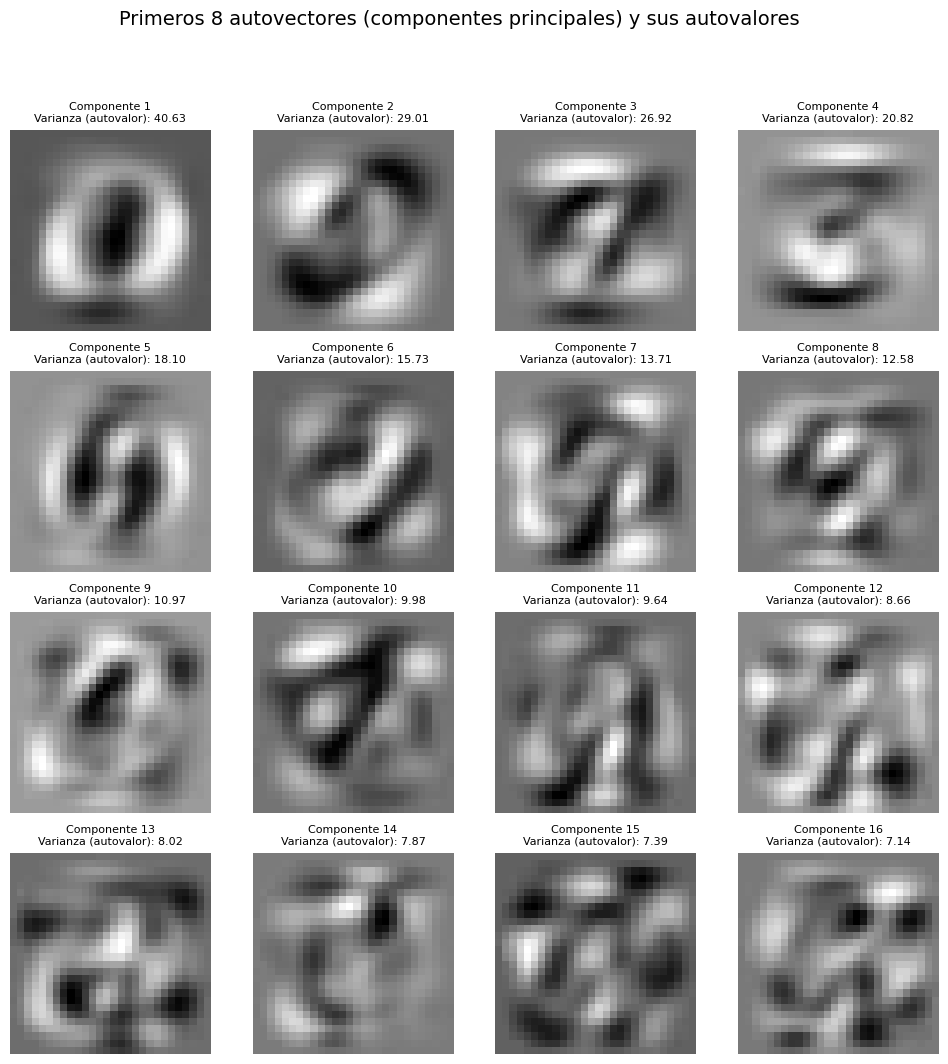

In [12]:
# Obtener los autovectores y autovalores de la PCA
components = pca_90.components_  # Los autovectores (componentes principales)
explained_variance = pca_90.explained_variance_  # Los autovalores (varianza explicada por cada componente)

# Seleccionar los 8 primeros autovectores y sus autovalores
top_n = 16
top_components = components[:top_n]  # Los primeros 8 autovectores
top_variance = explained_variance[:top_n]  # Los primeros 8 autovalores

# Crear una figura para mostrar los autovectores
fig, axes = plt.subplots(4, 4, figsize=(12, 12))  # 2 filas, 4 columnas
axes = axes.ravel()

# Graficar los autovectores
for i in range(top_n):
    ax = axes[i]
    ax.imshow(top_components[i].reshape(28, 28), cmap='gray')  # Redimensionar cada autovector a 28x28 para que sea visible
    ax.set_title(f"Componente {i+1}\nVarianza (autovalor): {top_variance[i]:.2f}" , fontsize=8)
    ax.axis('off')  # Ocultar los ejes

# Título general de la figura
plt.suptitle(f"Primeros 8 autovectores (componentes principales) y sus autovalores", fontsize=14)
plt.show()



#### Reconstrucción de una imagen como suma de su proyección en las componnetes principales

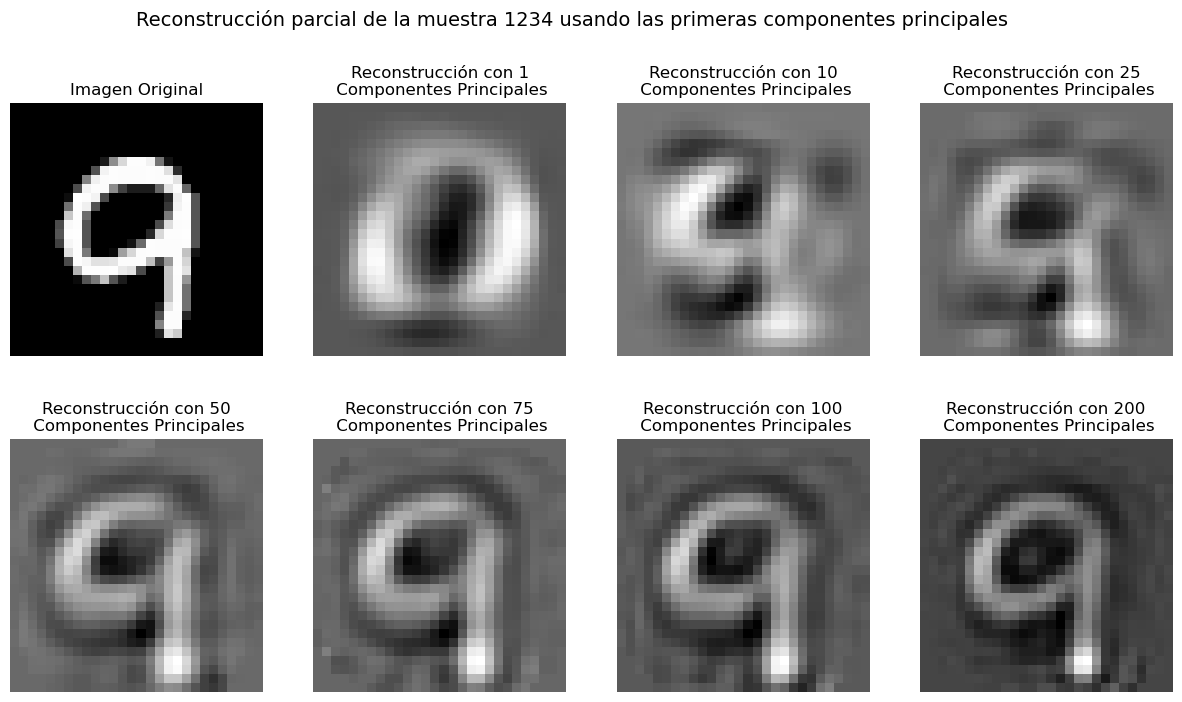

In [13]:


# Seleccionar una imagen de prueba (por ejemplo, la primera muestra del conjunto de datos)
sample_index = 1234  # Puedes cambiar el índice para ver otras imágenes
sample_image = X_test[sample_index]  # Usamos una muestra del conjunto de datos de prueba

# Escalar la muestra de entrada
X_sample_scaled = scaler.transform([sample_image])  # Escalar la imagen

# Proyección de la muestra sobre las componentes principales
X_sample_pca = pca_90.transform(X_sample_scaled)  # Proyectar la muestra

# Obtener las primeras 200 proyecciones
projections = X_sample_pca[0, :200]  

# Obtener las componentes principales (autovectores)
components = pca_90.components_[:200]  # Tomar las primeras 8 componentes

dimension_espacio = [1,10,25,50,75,100, 200]

# Crear la figura para mostrar las reconstrucciones
fig, axes = plt.subplots(2, 4, figsize=(15, 8))  # 2 filas, 4 columnas para mostrar 8 proyecciones
axes = axes.ravel()

# Mostrar la reconstrucción de la imagen utilizando las proyecciones y los autovectores
axes[0].imshow(sample_image.reshape(28, 28), cmap='gray')
axes[0].set_title("Imagen Original")
axes[0].axis('off')

for i, dimension in enumerate(dimension_espacio):
    ax = axes[i+1]
    # Multiplicar la proyección por la componente principal (autovector)
    reconstructed_image = np.sum([projections[j] * components[j] for j in range(dimension)], axis=0)
    
    # Mostrar la reconstrucción parcial de la imagen
    ax.imshow(reconstructed_image.reshape(28, 28), cmap='gray')  # Redimensionar a la forma de imagen MNIST
    ax.set_title(f"Reconstrucción con {dimension}\n Componentes Principales")
    ax.axis('off')  # Ocultar los ejes para una visualización más limpia

# Título general de la figura
plt.suptitle(f"Reconstrucción parcial de la muestra {sample_index} usando las primeras componentes principales", fontsize=14)
plt.show()



